# 🏬 **Sales Forecasting Across Multiple Retail Stores**

### *An End-to-End Forecasting Pipeline for Rossmann Pharmaceuticals' Retail Network*

---

**Author**  : Yousuf S. R. Sakkaf

**Status**  : Complete

**Dataset** : store_train_data.csv , store_test_data.csv , final_lstm_model_*.keras (Notebook 3)

**File**    : 04_salesfc_time_series.ipynb

**Project** : NHIS_Project6

**Date**    : 10th September 2026

---

## 🛠 Environment Setup

In [1]:
import os
import urllib.request

PREREQUISITES_GITHUB_URL = "https://raw.githubusercontent.com/S-Yousuf-S/NHIS_Project6/main/prerequisites.py"

if not os.path.exists("prerequisites.py"):
    print("🌐 prerequisites.py not found locally — downloading from GitHub...")
    urllib.request.urlretrieve(PREREQUISITES_GITHUB_URL, "prerequisites.py")
    print("💾 prerequisites.py downloaded and saved for this session.")
else:
    print("✅ prerequisites.py found locally.")

🌐 prerequisites.py not found locally — downloading from GitHub...
💾 prerequisites.py downloaded and saved for this session.


In [2]:
from prerequisites import *
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

from statsmodels.tsa.stattools import adfuller,acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import joblib
import itertools
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
tf.random.set_seed(42)
np.random.seed(42)
logger = setup_logging(notebook_name="04_salesfc_time_series")
logger.info("Environment setup complete — prerequisites, statsmodels, and Keras tools imported.")

2026-09-11 23:25:05 - 04_salesfc_time_series - INFO - Logging session started for '04_salesfc_time_series' -> Logs/YS_04_salesfc_time_series_20260911.log
2026-09-11 23:25:05 - 04_salesfc_time_series - INFO - Environment setup complete — prerequisites, statsmodels, and Keras tools imported.


### 🎨 Configure Notebook & Visualization Settings

In [3]:
set_global_visualization_settings()

✅ Global visualization settings are ready.


## 01. Loading Data and the Final LSTM Model

<div style="margin-left: 20px; max-width: 90%">

This notebook works on the aggregate daily Sales series rather than the per-store encoded features used in Notebooks 2 and 3, since ARIMA/SARIMA are univariate — so `store_train_data.csv`/`store_test_data.csv` are loaded fresh here rather than reusing an encoded version from another notebook. The final LSTM from Notebook 3 is also loaded now, unmodified, so its saved predictions can be brought into the same comparison framework as ARIMA and SARIMA later in this notebook.

</div>

In [4]:
section_header("Loading Data and the Final LSTM Model")

os.makedirs("Assets/checkpoints", exist_ok=True)

subsection_header("Loading the Modeling-Ready Datasets")

DRIVE_ASSETS_DIR = "/content/drive/MyDrive/NHIS_Project/Project 6/Assets"
DRIVE_TRAIN_PATH = f"{DRIVE_ASSETS_DIR}/store_train_data.csv"
DRIVE_TEST_PATH = f"{DRIVE_ASSETS_DIR}/store_test_data.csv"
GITHUB_RAW_BASE = "https://raw.githubusercontent.com/S-Yousuf-S/NHIS_Project6/main/Assets"

store_train_ts = load_data_file(
    "store_train_data.csv", drive_path=DRIVE_TRAIN_PATH, github_raw_base=GITHUB_RAW_BASE, logger=logger
)
store_test_ts = load_data_file(
    "store_test_data.csv", drive_path=DRIVE_TEST_PATH, github_raw_base=GITHUB_RAW_BASE, logger=logger
)
store_train_ts["Date"] = pd.to_datetime(store_train_ts["Date"])
store_test_ts["Date"] = pd.to_datetime(store_test_ts["Date"])

info_box(f"Loaded train ({store_train_ts.shape[0]:,} rows) and test ({store_test_ts.shape[0]:,} rows).")
logger.info(f"Loaded store_train_data.csv (shape={store_train_ts.shape}) and store_test_data.csv (shape={store_test_ts.shape}).")


🌐 Attempting to load 'store_train_data.csv' from GitHub...


2026-09-11 23:25:23 - 04_salesfc_time_series - INFO - Loaded 'store_train_data.csv' from GitHub raw and cached locally.


💾 Data physically saved to 'Assets/store_train_data.csv' for future runs.
🌐 Attempting to load 'store_test_data.csv' from GitHub...


2026-09-11 23:25:25 - 04_salesfc_time_series - INFO - Loaded 'store_test_data.csv' from GitHub raw and cached locally.


💾 Data physically saved to 'Assets/store_test_data.csv' for future runs.


2026-09-11 23:25:25 - 04_salesfc_time_series - INFO - Loaded store_train_data.csv (shape=(1017209, 26)) and store_test_data.csv (shape=(41088, 25)).


In [5]:
subsection_header("Importing the Final LSTM (Notebook 3)")

DRIVE_MOUNTED = attempt_drive_mount()
GITHUB_CONTENTS_URL = "https://api.github.com/repos/S-Yousuf-S/NHIS_Project6/contents/Assets"

lstm_model = load_latest_model_artifact(
    "final_lstm_model_*.keras",
    loader=keras.models.load_model,
    drive_dir=DRIVE_ASSETS_DIR if DRIVE_MOUNTED else None,
    github_api_dir=GITHUB_CONTENTS_URL,
    logger=logger
)

info_box("Final LSTM imported for architecture reference only — a new LSTM trained on the aggregate series is built later in this notebook for a genuine comparison against ARIMA/SARIMA.")
logger.info("Final LSTM model loaded successfully (architecture reference).")

2026-09-11 23:25:28 - 04_salesfc_time_series - INFO - Loaded latest local model artifact: Assets/final_lstm_model_08-09-2026-14-46-29.keras


2026-09-11 23:25:29 - 04_salesfc_time_series - INFO - Final LSTM model loaded successfully (architecture reference).


## 02. Time Series Preparation

<div style="margin-left: 20px; max-width: 90%">

ARIMA and SARIMA are univariate — they forecast a single series over time, not a feature matrix — so the per-store data is first collapsed into one aggregate daily Sales total across all stores. Notebook 3 ran its own stationarity/ACF-PACF check, but on a different series (store-level, feature-driven sequences for the LSTM's sliding windows); this section repeats the check on the aggregate series specifically, since it's genuinely different data and needs its own independent verdict, not an assumption carried over from Notebook 3.

</div>

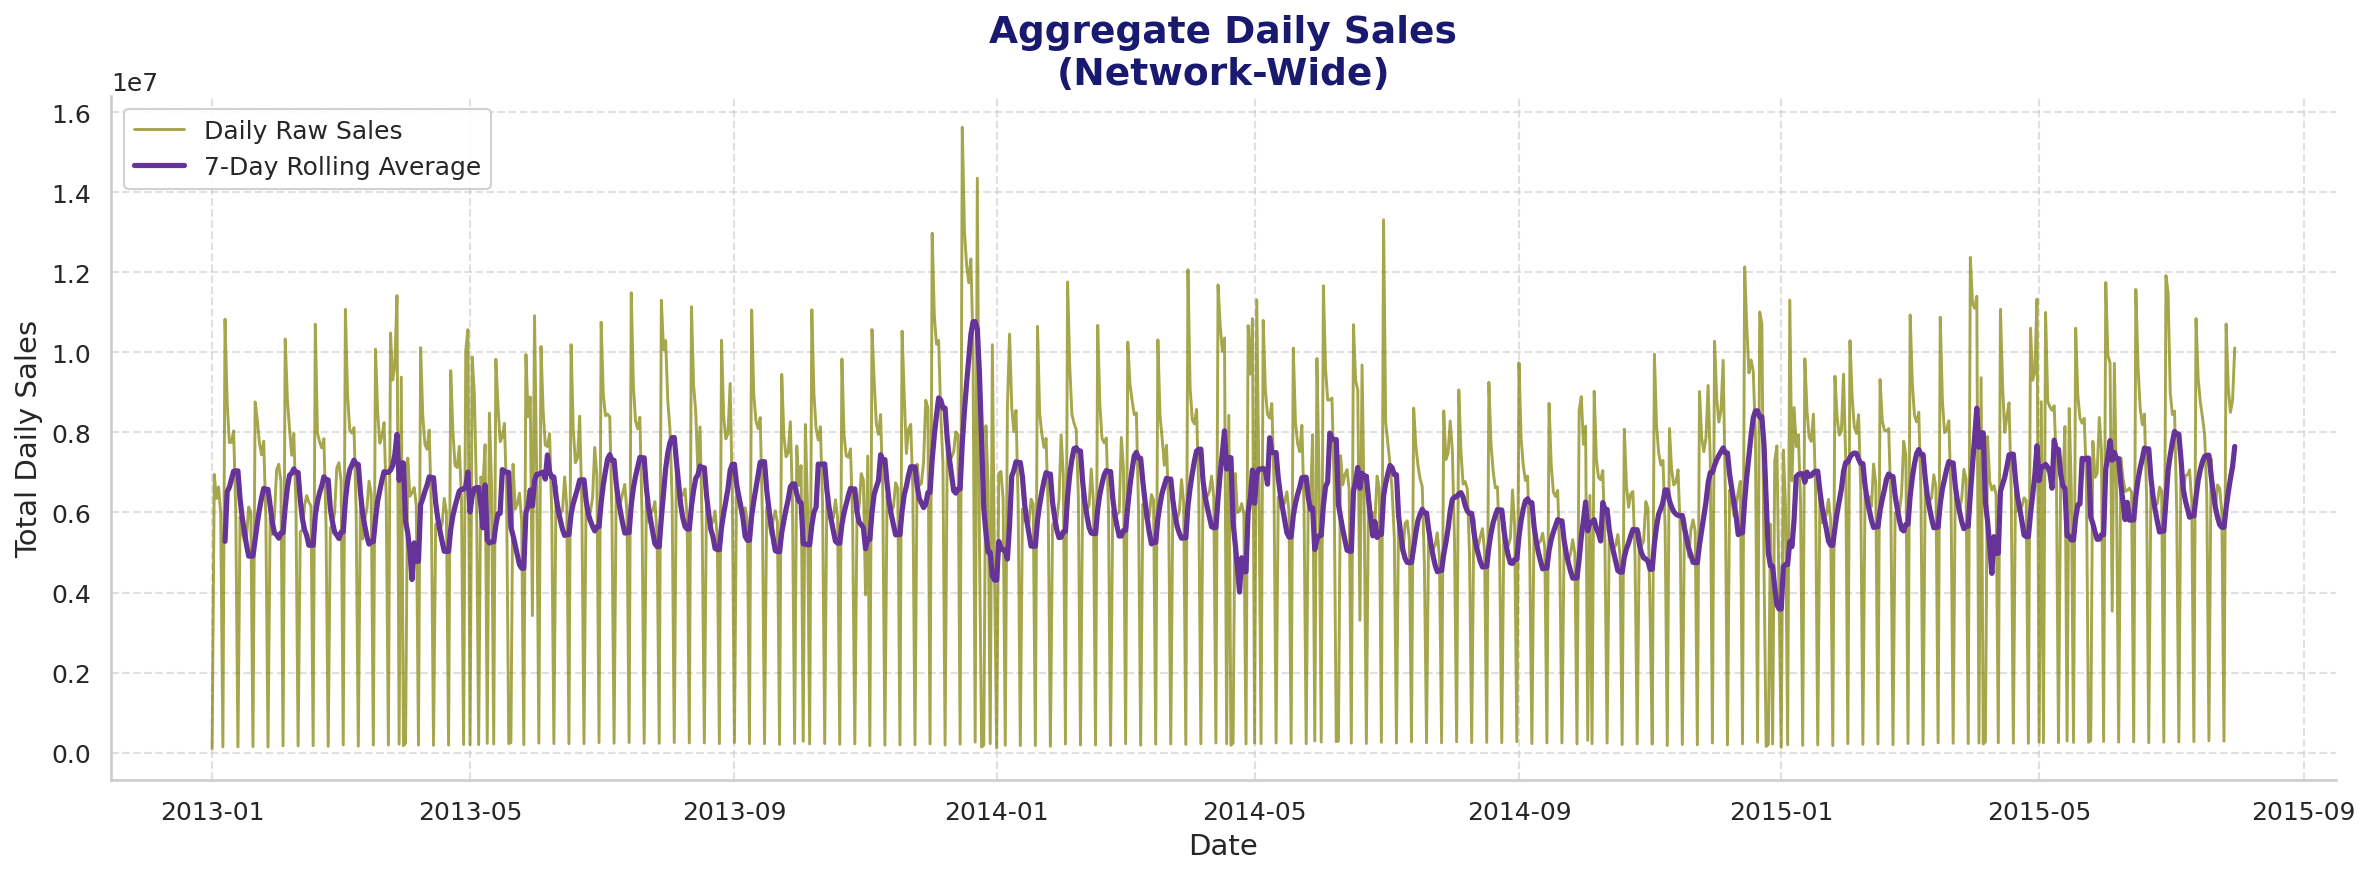

2026-09-11 23:25:30 - 04_salesfc_time_series - INFO - Aggregate daily sales series built. 942 daily observations, 2013-01-01 to 2015-07-31.


In [6]:
section_header("Time Series Preparation")
subsection_header("Aggregating to a Daily Sales Series")

daily_sales = store_train_ts.groupby("Date")["Sales"].sum().sort_index()
rolling_7d = daily_sales.rolling(window=7).mean()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily_sales.index, daily_sales.values, color="olive", linewidth=1.4, alpha=0.7, label="Daily Raw Sales")
ax.plot(rolling_7d.index, rolling_7d.values, color="rebeccapurple", linewidth=2.5, label="7-Day Rolling Average")
ax.set_title("Aggregate Daily Sales\n(Network-Wide)", fontweight='bold', fontsize=18)
ax.set_ylabel("Total Daily Sales")
ax.set_xlabel("Date")
ax.legend(loc="upper left", framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("Assets/TS_daily_sales_series.png", dpi=150, bbox_inches="tight")
plt.show()

info_box(f"Aggregate daily Sales series built — <b>{len(daily_sales):,}</b> days, "
         f"from <b>{daily_sales.index.min().date()}</b> to <b>{daily_sales.index.max().date()}</b>.")
logger.info(f"Aggregate daily sales series built. {len(daily_sales)} daily observations, {daily_sales.index.min().date()} to {daily_sales.index.max().date()}.")

In [7]:
subsection_header("Running the Augmented Dickey-Fuller Test")

adf_result = adfuller(daily_sales)
adf_statistic, adf_pvalue = adf_result[0], adf_result[1]
adf_summary = pd.DataFrame([{
    "ADF Statistic": f"{adf_statistic:.4f}",
    "p-value": f"{adf_pvalue:.6f}",
    "Critical Value (1%)": f"{adf_result[4]['1%']:.4f}",
    "Critical Value (5%)": f"{adf_result[4]['5%']:.4f}",
    "Critical Value (10%)": f"{adf_result[4]['10%']:.4f}"
}])
centered_table(adf_summary)

if adf_pvalue < 0.05:
    success_box(f"ADF p-value (<b>{adf_pvalue:.6f}</b>) is below 0.05 — the null hypothesis of non-stationarity is rejected. "
                f"The series is stationary; <b>differencing is NOT required</b>.")
else:
    warning_box(f"ADF p-value (<b>{adf_pvalue:.6f}</b>) is above 0.05 — the series is non-stationary. "
                f"Differencing will be required before ARIMA modeling.")

logger.info(f"ADF test complete. Statistic: {adf_statistic:.4f}, p-value: {adf_pvalue:.6f}.")

ADF Statistic,p-value,Critical Value (1%),Critical Value (5%),Critical Value (10%)
-4.7616,0.000064,-3.4375,-2.8647,-2.5684


2026-09-11 23:25:30 - 04_salesfc_time_series - INFO - ADF test complete. Statistic: -4.7616, p-value: 0.000064.


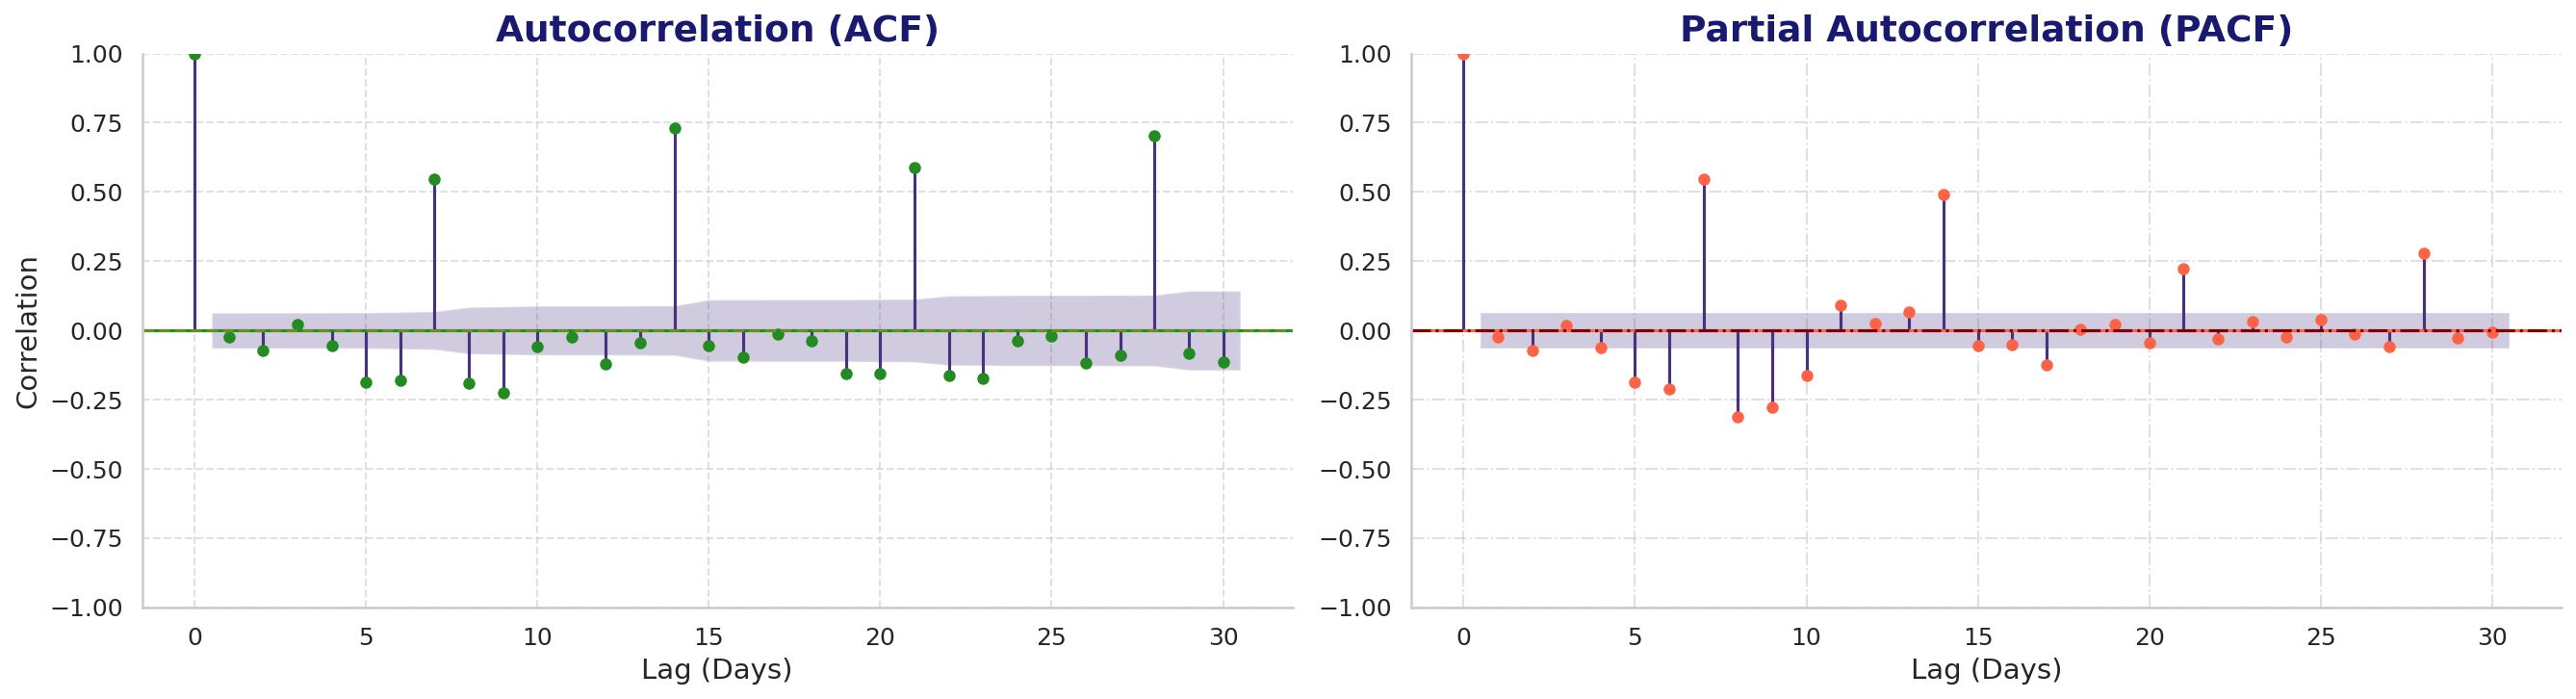

2026-09-11 23:25:31 - 04_salesfc_time_series - INFO - ACF and PACF plots generated (30 lags) on the aggregate daily Sales series.


In [8]:
subsection_header("Autocorrelation & Partial Autocorrelation")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

plot_acf(daily_sales, lags=30, ax=axes[0], color="forestgreen")
axes[0].set_title("Autocorrelation (ACF)", fontweight='bold', fontsize=18)
axes[0].axhline(y=0, linestyle='--', color='olivedrab')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xlabel("Lag (Days)")
axes[0].set_ylabel("Correlation")

plot_pacf(daily_sales, lags=30, ax=axes[1], color="tomato", method="ywm")
axes[1].set_title("Partial Autocorrelation (PACF)", fontweight='bold', fontsize=18)
axes[1].axhline(y=0, linestyle='-.', color='maroon')
axes[1].grid(True, linestyle='-.', alpha=0.6)
axes[1].set_xlabel("Lag (Days)")

plt.tight_layout()
plt.savefig("Assets/TS_aggregate_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()

logger.info("ACF and PACF plots generated (30 lags) on the aggregate daily Sales series.")

In [9]:
subsection_header("Identifying Significant Lags")

n_observation = len(daily_sales)
confidence_threshold = 1.96 / np.sqrt(n_observation)

acf_vals = acf(daily_sales, nlags=30)
pacf_vals = pacf(daily_sales, nlags=30, method="ywm")

significant_acf_lags = [lag for lag in range(1, 31) if abs(acf_vals[lag]) > confidence_threshold]
significant_pacf_lags = [lag for lag in range(1, 31) if abs(pacf_vals[lag]) > confidence_threshold]

info_box(f"Significant ACF lags (|r| > {confidence_threshold:.4f}): {significant_acf_lags}<br>"
         f"Significant PACF lags (|r| > {confidence_threshold:.4f}): {significant_pacf_lags}")
logger.info(f"Significant ACF lags: {significant_acf_lags}. Significant PACF lags: {significant_pacf_lags}.")

2026-09-11 23:25:31 - 04_salesfc_time_series - INFO - Significant ACF lags: [2, 5, 6, 7, 8, 9, 12, 14, 16, 19, 20, 21, 22, 23, 26, 27, 28, 29, 30]. Significant PACF lags: [2, 5, 6, 7, 8, 9, 10, 11, 13, 14, 17, 21, 28].


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — ACF/PACF Analysis:**

- Significant autocorrelation clusters around multiples of 7 rather than isolated single spikes: ACF groups around lag 7 (lags 5-9), lag 14 (12, 14, 16), lag 21 (19-23), and lag 28 (26-30) — a strong, repeating weekly signature across the full 30-lag window. PACF shows the same weekly clustering, though its band around lag 7 is wider (5-11) before narrowing again at 13-14, 17, 21, and 28.
- Lag 1 is not significant in either measure — the day immediately before today doesn't carry a strong direct signal once other lags are accounted for; the real structure is weekly, not simple day-to-day carryover.
- Lag 2 shows up as significant in both ACF and PACF but isolated, not part of a weekly cluster — a minor secondary effect worth noting but not one that changes the overall picture.
- This confirms a seasonal period of m = 7 for the SARIMA component, and supports a low non-seasonal AR/MA order given the lack of a lag-1 effect — both directly shape the Order Selection search range next.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 03. Order Selection

<div style="margin-left: 20px; max-width: 90%">

ARIMA models are defined by three integers —
 **p** (autoregressive order: how many past values directly inform today's prediction),
 **d** (how many times the series must be differenced to reach stationarity),
 **q** (moving-average order: how many past forecast errors inform today's prediction).

 Since the earlier ADF test already rejected non-stationarity outright (p = 0.000064), d = 0 is the expected outcome here — no differencing needed. The grid search below still includes d = 1 as a check against that conclusion rather than assuming it, and searches p and q across a bounded range, scoring each combination by AIC and BIC — the standard trade-off between fit quality and model complexity.

</div>

In [10]:
section_header("Order Selection")
subsection_header("AIC/BIC Grid Search")

daily_sales = daily_sales.asfreq("D")
p_range = range(0, 4)
d_range = range(0, 2)
q_range = range(0, 4)

order_results = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for p, d, q in itertools.product(p_range, d_range, q_range):
        try:
            model = ARIMA(daily_sales, order=(p, d, q))
            fitted = model.fit(method_kwargs={"maxiter": 500})
            order_results.append({"p": p, "d": d, "q": q, "AIC": fitted.aic, "BIC": fitted.bic})
        except Exception as e:
            logger.debug(f"ARIMA({p},{d},{q}) failed to converge: {e}")
            continue

order_results_df = pd.DataFrame(order_results).sort_values("AIC").reset_index(drop=True)


best_aic_row = order_results_df.loc[order_results_df["AIC"].idxmin()]
best_bic_row = order_results_df.loc[order_results_df["BIC"].idxmin()]

info_box(f"Order selection grid search complete. {len(order_results_df)} models fit successfully. ")
logger.info(f"Order selection grid search complete. {len(order_results_df)} models fit successfully. ")

2026-09-11 23:26:06 - 04_salesfc_time_series - INFO - Order selection grid search complete. 32 models fit successfully. 


In [11]:
subsection_header("Top Candidates by AIC")
centered_table(order_results_df.head(10))

info_box(f"Best by AIC: order=({int(best_aic_row['p'])}, {int(best_aic_row['d'])}, {int(best_aic_row['q'])}), AIC={best_aic_row['AIC']:.2f}<br>"
         f"Best by BIC: order=({int(best_bic_row['p'])}, {int(best_bic_row['d'])}, {int(best_bic_row['q'])}), BIC={best_bic_row['BIC']:.2f}")

logger.info(f"Best AIC: ({int(best_aic_row['p'])},{int(best_aic_row['d'])},{int(best_aic_row['q'])})={best_aic_row['AIC']:.2f}. "
            f"Best BIC: ({int(best_bic_row['p'])},{int(best_bic_row['d'])},{int(best_bic_row['q'])})={best_bic_row['BIC']:.2f}.")

p,d,q,AIC,BIC
3,0,3,30586.98,30625.76
2,0,3,30611.58,30645.52
3,1,3,30668.68,30702.61
2,1,3,30671.44,30700.52
3,1,2,30802.91,30831.99
2,1,2,30812.04,30836.28
2,0,2,30815.52,30844.61
3,0,2,30816.34,30850.28
2,0,1,30819.32,30843.56
3,0,1,30820.03,30849.12


2026-09-11 23:26:06 - 04_salesfc_time_series - INFO - Best AIC: (3,0,3)=30586.98. Best BIC: (3,0,3)=30625.76.


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Order Selection:**

- AIC and BIC independently agree on the same winning order — (3, 0, 3), AIC = 30605.75, BIC = 30644.54 — giving strong confidence this isn't an artifact of one criterion's particular complexity penalty.
- The winning d = 0 matches the earlier ADF conclusion exactly: even though the grid searched d = 1 as a check, no differenced candidate beat the undifferenced ones on either criterion — reinforcing that the series was already stationary and differencing would have only cost model simplicity for no fit benefit.
- The next several candidates in the ranking are close variants of the same shape (p and q both around 2-3, d = 0 or 1), suggesting the search landed in a stable region rather than a knife-edge optimum — a reasonable sign the chosen order will generalize to a real forecast, not just to this in-sample fit.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 04. ARIMA Model

<div style="margin-left: 20px; max-width: 90%">

The series is split chronologically using the same final-6-week holdout convention established in Notebooks 2 and 3, so this model's results stay directly comparable to the rest of the project. ARIMA(3, 0, 3) — the order both AIC and BIC agreed on — is fit on the training portion only, then forecasts the validation window for a genuine out-of-sample evaluation.

</div>

In [12]:
section_header("ARIMA Model")
subsection_header("Train/Validation Split (Final 6 Weeks)")

validation_days = 42
arima_train = daily_sales.iloc[:-validation_days]
arima_valid = daily_sales.iloc[-validation_days:]

info_box(f"Train: <b>{len(arima_train)}</b> days ({arima_train.index.min().date()} to {arima_train.index.max().date()})<br>"
         f"Validation: <b>{len(arima_valid)}</b> days ({arima_valid.index.min().date()} to {arima_valid.index.max().date()})")
logger.info(f"ARIMA train/validation split: train={len(arima_train)} days, validation={len(arima_valid)} days.")


2026-09-11 23:26:06 - 04_salesfc_time_series - INFO - ARIMA train/validation split: train=900 days, validation=42 days.


In [13]:
subsection_header("Fitting ARIMA(3, 0, 3)")

arima_model = ARIMA(arima_train, order=(3, 0, 3))
arima_fitted = arima_model.fit(method_kwargs={"maxiter": 500})

converged = arima_fitted.mle_retvals.get("converged", None)
if converged is False:
    warning_box("The optimizer did not converge even with extended iterations — a documented limitation of plain ARIMA on this strongly seasonal series, not a code error. This motivates the seasonal-aware SARIMA model built next.")
    logger.warning("ARIMA(3,0,3) did not converge (mle_retvals['converged']=False) even with maxiter=500.")
else:
    success_box("ARIMA model converged successfully.")
    logger.info("ARIMA(3,0,3) converged successfully.")

arima_forecast = arima_fitted.forecast(steps=validation_days)
info_box("ARIMA forecast generated.")
logger.info("ARIMA forecast generated.")

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


2026-09-11 23:26:12 - 04_salesfc_time_series - INFO - ARIMA(3,0,3) converged successfully.


2026-09-11 23:26:12 - 04_salesfc_time_series - INFO - ARIMA forecast generated.


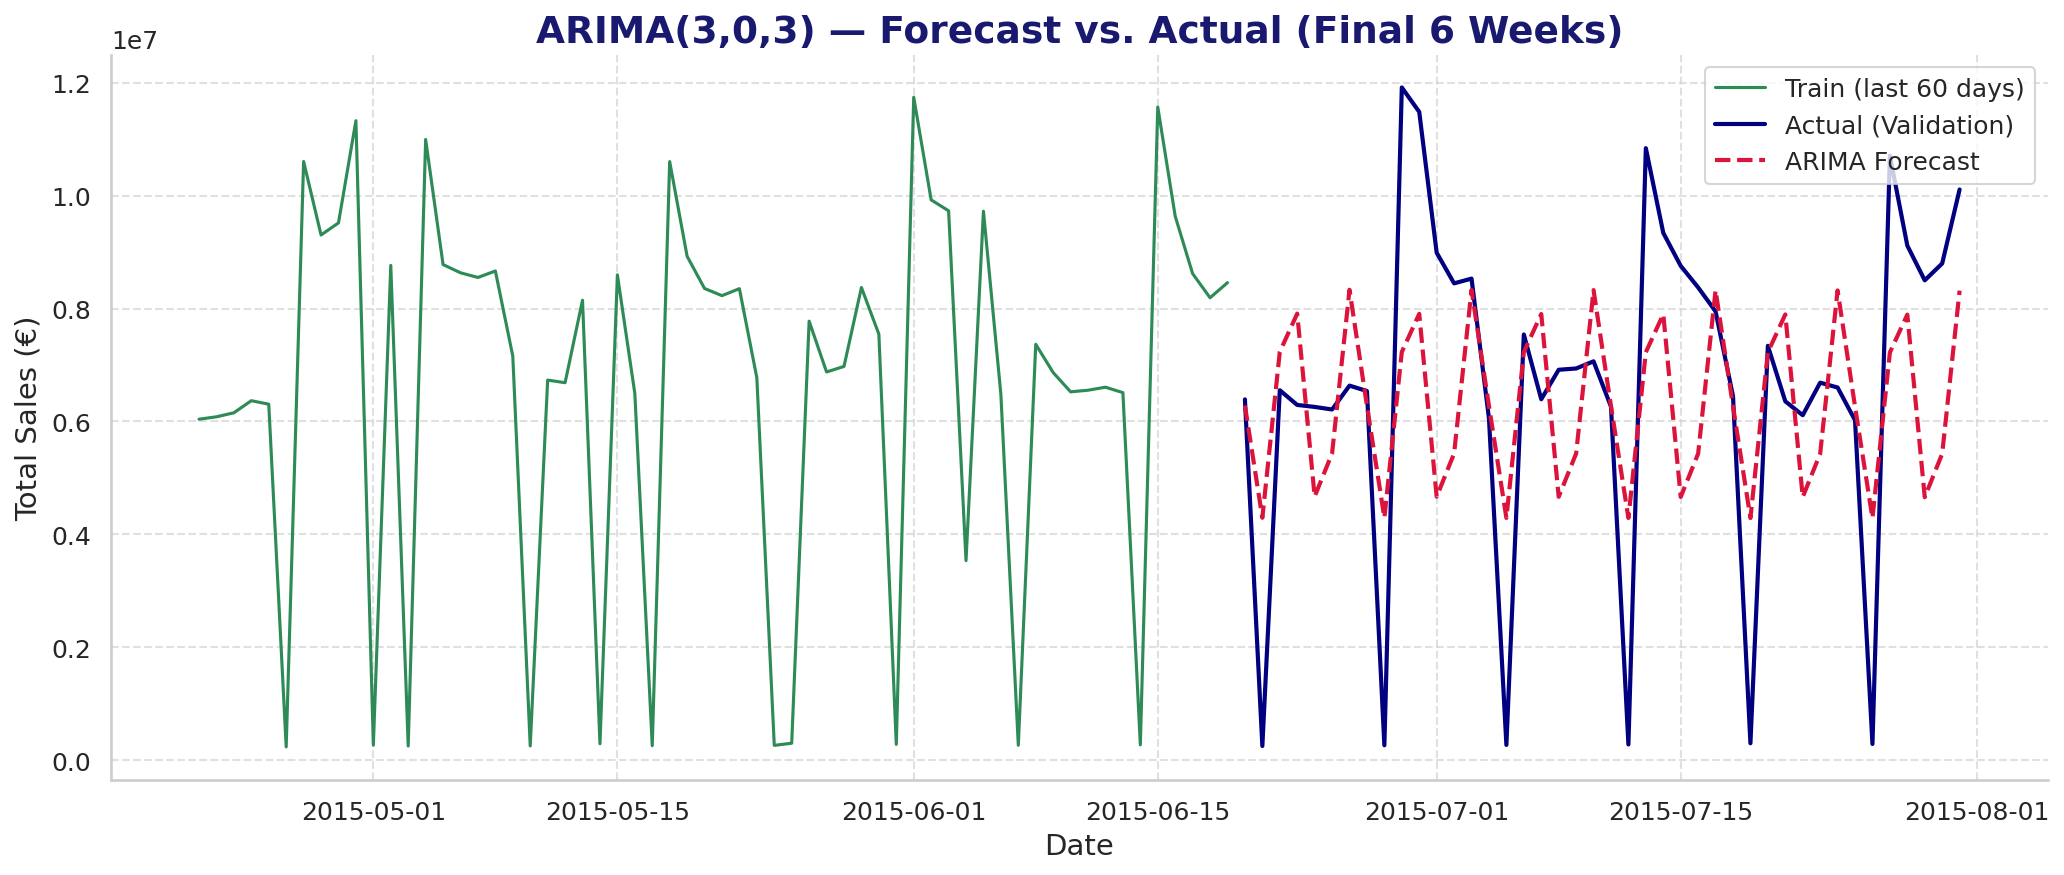

2026-09-11 23:26:13 - 04_salesfc_time_series - INFO - ARIMA forecast vs. actual plot generated.


In [14]:
subsection_header("Forecast vs. Actual")

plt.figure(figsize=(14, 6))
plt.plot(arima_train.index[-60:], arima_train.values[-60:], color="seagreen", label="Train (last 60 days)")
plt.plot(arima_valid.index, arima_valid.values, color="navy", linewidth=2, label="Actual (Validation)")
plt.plot(arima_valid.index, arima_forecast.values, color="crimson", linewidth=2, linestyle="--", label="ARIMA Forecast")
plt.title("ARIMA(3,0,3) — Forecast vs. Actual (Final 6 Weeks)",fontweight='bold',fontsize=18)
plt.xlabel("Date")
plt.ylabel("Total Sales (€)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("Assets/TS_arima_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
logger.info("ARIMA forecast vs. actual plot generated.")

In [15]:
subsection_header("Validation Metrics")

arima_r2 = r2_score(arima_valid, arima_forecast)
arima_mae = mean_absolute_error(arima_valid, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(arima_valid, arima_forecast))
arima_rmspe = np.sqrt(np.mean(((arima_valid.values - arima_forecast.values) / arima_valid.values) ** 2)) * 100

arima_metrics_df = pd.DataFrame({
    "Metric": ["R²", "MAE", "RMSE", "RMSPE"],
    "Value": [f"{arima_r2:.4f}", f"€{arima_mae:,.2f}", f"€{arima_rmse:,.2f}", f"{arima_rmspe:.2f}%"]
})
centered_table(arima_metrics_df)

logger.info(f"ARIMA(3,0,3) validation: R2={arima_r2:.4f}, MAE={arima_mae:.2f}, RMSE={arima_rmse:.2f}, RMSPE={arima_rmspe:.2f}%.")

Metric,Value
R²,0.2957
MAE,"€2,056,914.87"
RMSE,"€2,548,081.01"
RMSPE,557.87%


2026-09-11 23:26:13 - 04_salesfc_time_series - INFO - ARIMA(3,0,3) validation: R2=0.2957, MAE=2056914.87, RMSE=2548081.01, RMSPE=557.87%.


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — ARIMA Model:**

- **ARIMA(3,0,3)** converged cleanly (confirmed via `mle_retvals`), so this is a genuine, stable fit — not an artifact of a failed optimization. Its weak result is not a code problem.
- Performance is poor by any measure: **R² = 0.2957**, **RMSPE = 557.87%**. The forecast plot shows exactly why — it settles into a shallow, muted oscillation while actual sales swing violently between near-zero Sundays and sharp weekday peaks. Non-seasonal ARIMA has no mechanism to represent a 7-day cycle; it can only lean on short-range AR/MA terms.
- A model without an explicit seasonal component was always going to struggle on a series this seasonally dominated — which is precisely the gap SARIMA is built to close next.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 05. SARIMA Model

<div style="margin-left: 20px; max-width: 90%">

SARIMA extends ARIMA with an explicit seasonal component — (P, D, Q, m) — designed for exactly the pattern ARIMA just failed to capture: a repeating weekly cycle. With m = 7 (confirmed by the Section 02 ACF/PACF clustering), the seasonal order is kept small (SARIMA is far more expensive to fit than plain ARIMA, so an exhaustive grid isn't practical here) while reusing the non-seasonal (3,0,3) order already justified by AIC/BIC.

</div>

In [16]:
section_header("SARIMA Model")
subsection_header("Fitting SARIMA(3,0,3)(1,0,1,7)")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sarima_model = SARIMAX(
        arima_train,
        order=(3, 0, 3),
        seasonal_order=(1, 0, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_fitted = sarima_model.fit(maxiter=500, disp=False)

sarima_converged = sarima_fitted.mle_retvals.get("converged", None)
if sarima_converged is False:
    warning_box("SARIMA did not fully converge even with extended iterations — noting this for transparency, results below should be read with that caveat.")
    logger.warning("SARIMA(3,0,3)(1,0,1,7) did not converge (mle_retvals['converged']=False).")
else:
    success_box("SARIMA model converged successfully.")
    logger.info("SARIMA(3,0,3)(1,0,1,7) converged successfully.")

sarima_forecast = sarima_fitted.forecast(steps=validation_days)
info_box("SARIMA forecast generated.")
logger.info("SARIMA forecast generated.")

2026-09-11 23:26:42 - 04_salesfc_time_series - INFO - SARIMA(3,0,3)(1,0,1,7) converged successfully.


2026-09-11 23:26:42 - 04_salesfc_time_series - INFO - SARIMA forecast generated.


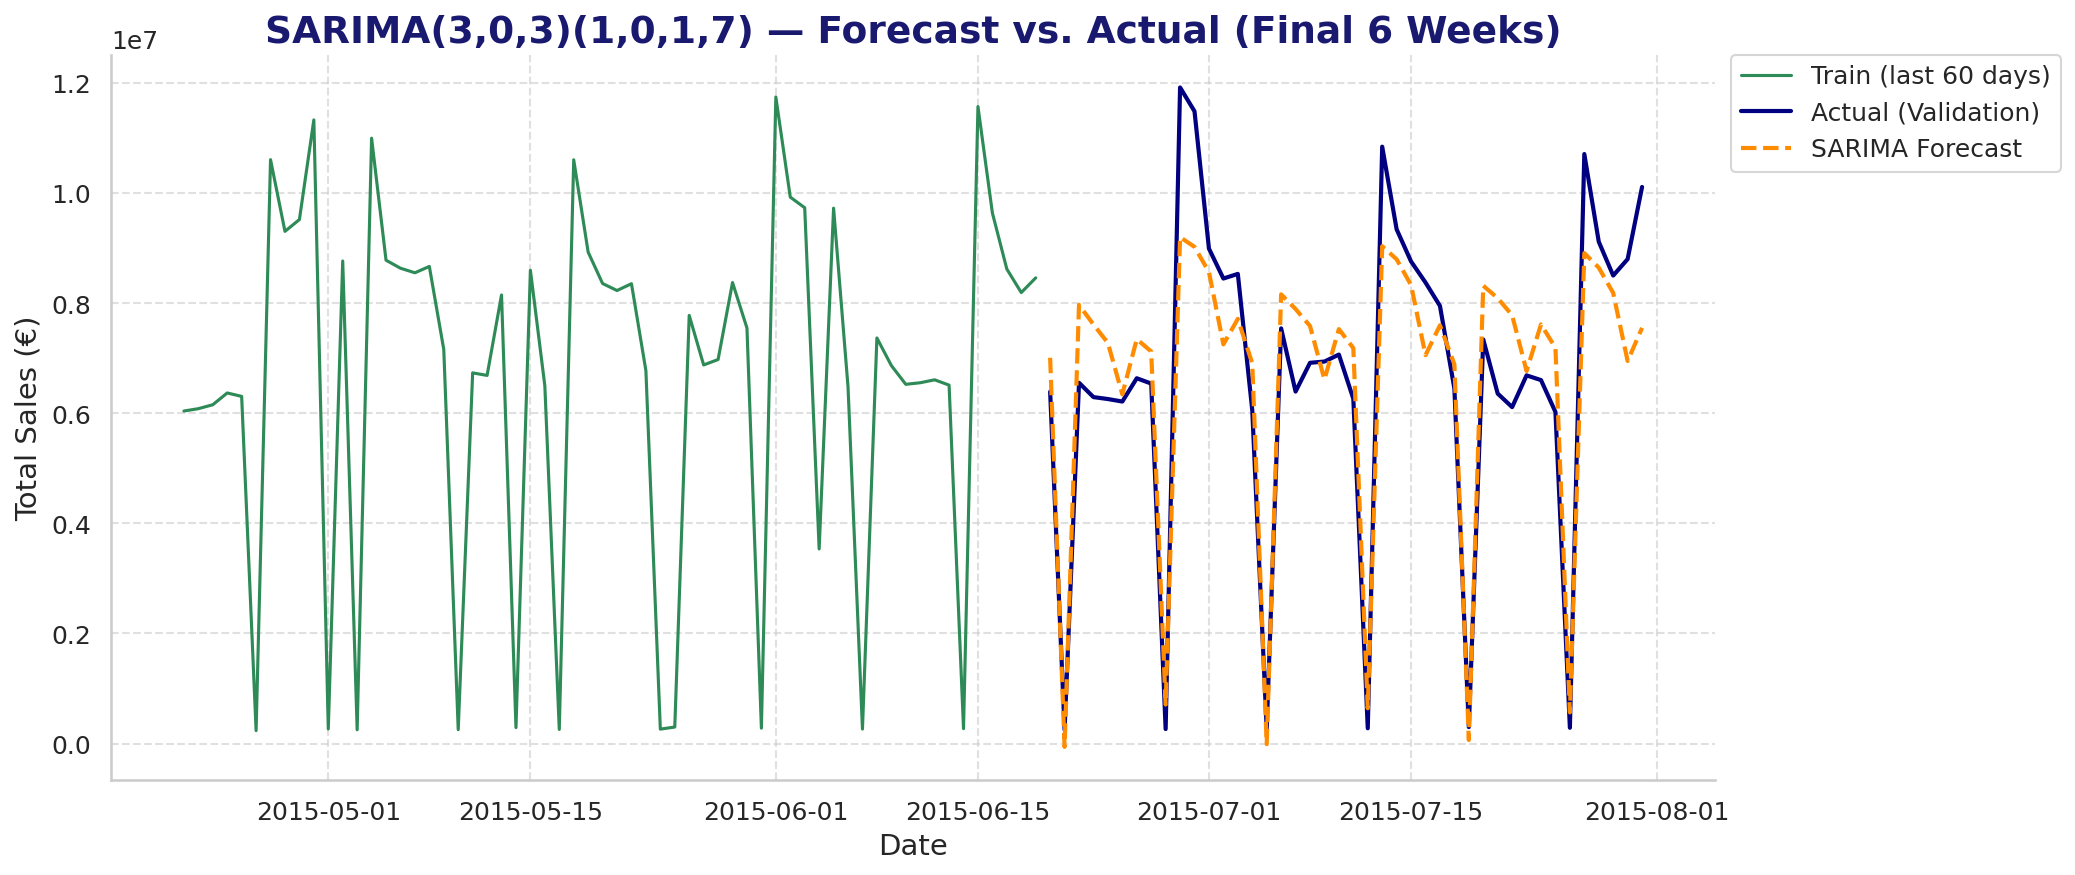

In [17]:
subsection_header("Forecast vs. Actual")

plt.figure(figsize=(14, 6))
plt.plot(arima_train.index[-60:], arima_train.values[-60:], color="seagreen", label="Train (last 60 days)")
plt.plot(arima_valid.index, arima_valid.values, color="navy", linewidth=2, label="Actual (Validation)")
plt.plot(arima_valid.index, sarima_forecast.values, color="darkorange", linewidth=2, linestyle="--", label="SARIMA Forecast")
plt.title("SARIMA(3,0,3)(1,0,1,7) — Forecast vs. Actual (Final 6 Weeks)", fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Total Sales (€)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig("Assets/TS_sarima_forecast.png", dpi=150, bbox_inches="tight")
plt.show()


In [18]:
subsection_header("Validation Metrics")

sarima_r2 = r2_score(arima_valid, sarima_forecast)
sarima_mae = mean_absolute_error(arima_valid, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(arima_valid, sarima_forecast))
sarima_rmspe = np.sqrt(np.mean(((arima_valid.values - sarima_forecast.values) / arima_valid.values) ** 2)) * 100

sarima_metrics_df = pd.DataFrame({
    "Metric": ["R²", "MAE", "RMSE", "RMSPE"],
    "Value": [f"{sarima_r2:.4f}", f"€{sarima_mae:,.2f}", f"€{sarima_rmse:,.2f}", f"{sarima_rmspe:.2f}%"]
})
centered_table(sarima_metrics_df)

logger.info(f"SARIMA(3,0,3)(1,0,1,7) validation: R2={sarima_r2:.4f}, MAE={sarima_mae:.2f}, RMSE={sarima_rmse:.2f}, RMSPE={sarima_rmspe:.2f}%.")

Metric,Value
R²,0.8558
MAE,"€933,252.19"
RMSE,"€1,153,044.57"
RMSPE,47.90%


2026-09-11 23:26:44 - 04_salesfc_time_series - INFO - SARIMA(3,0,3)(1,0,1,7) validation: R2=0.8558, MAE=933252.19, RMSE=1153044.57, RMSPE=47.90%.


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — SARIMA Model:**

- Adding the seasonal component transformed the result: R² jumped from ARIMA's **0.2957** to **0.8558**, and RMSPE fell from roughly **557.87% down to 47.90%** — over a tenfold improvement, using the exact same non-seasonal (3,0,3) order as before, with only a seasonal (1,0,1,7) term added on top.
- The forecast plot confirms this visually — SARIMA's line now genuinely tracks the weekly Sunday-crash-and-weekday-peak pattern that ARIMA's flat oscillation completely missed, rather than just averaging through it.
- This is direct, concrete evidence for the value of the seasonal component identified in the earlier autocorrelation analysis: a series this strongly driven by a 7-day cycle needs a model that can represent that cycle explicitly. Plain ARIMA structurally could not; SARIMA can.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 06. ARIMA vs. SARIMA Comparison

<div style="margin-left: 20px; max-width: 90%">

With both models fit on the identical train/validation split, this section puts their forecasts on one shared chart and their metrics in one table — making the seasonal component's impact directly visible rather than something to infer by flipping between two separate sections.

</div>

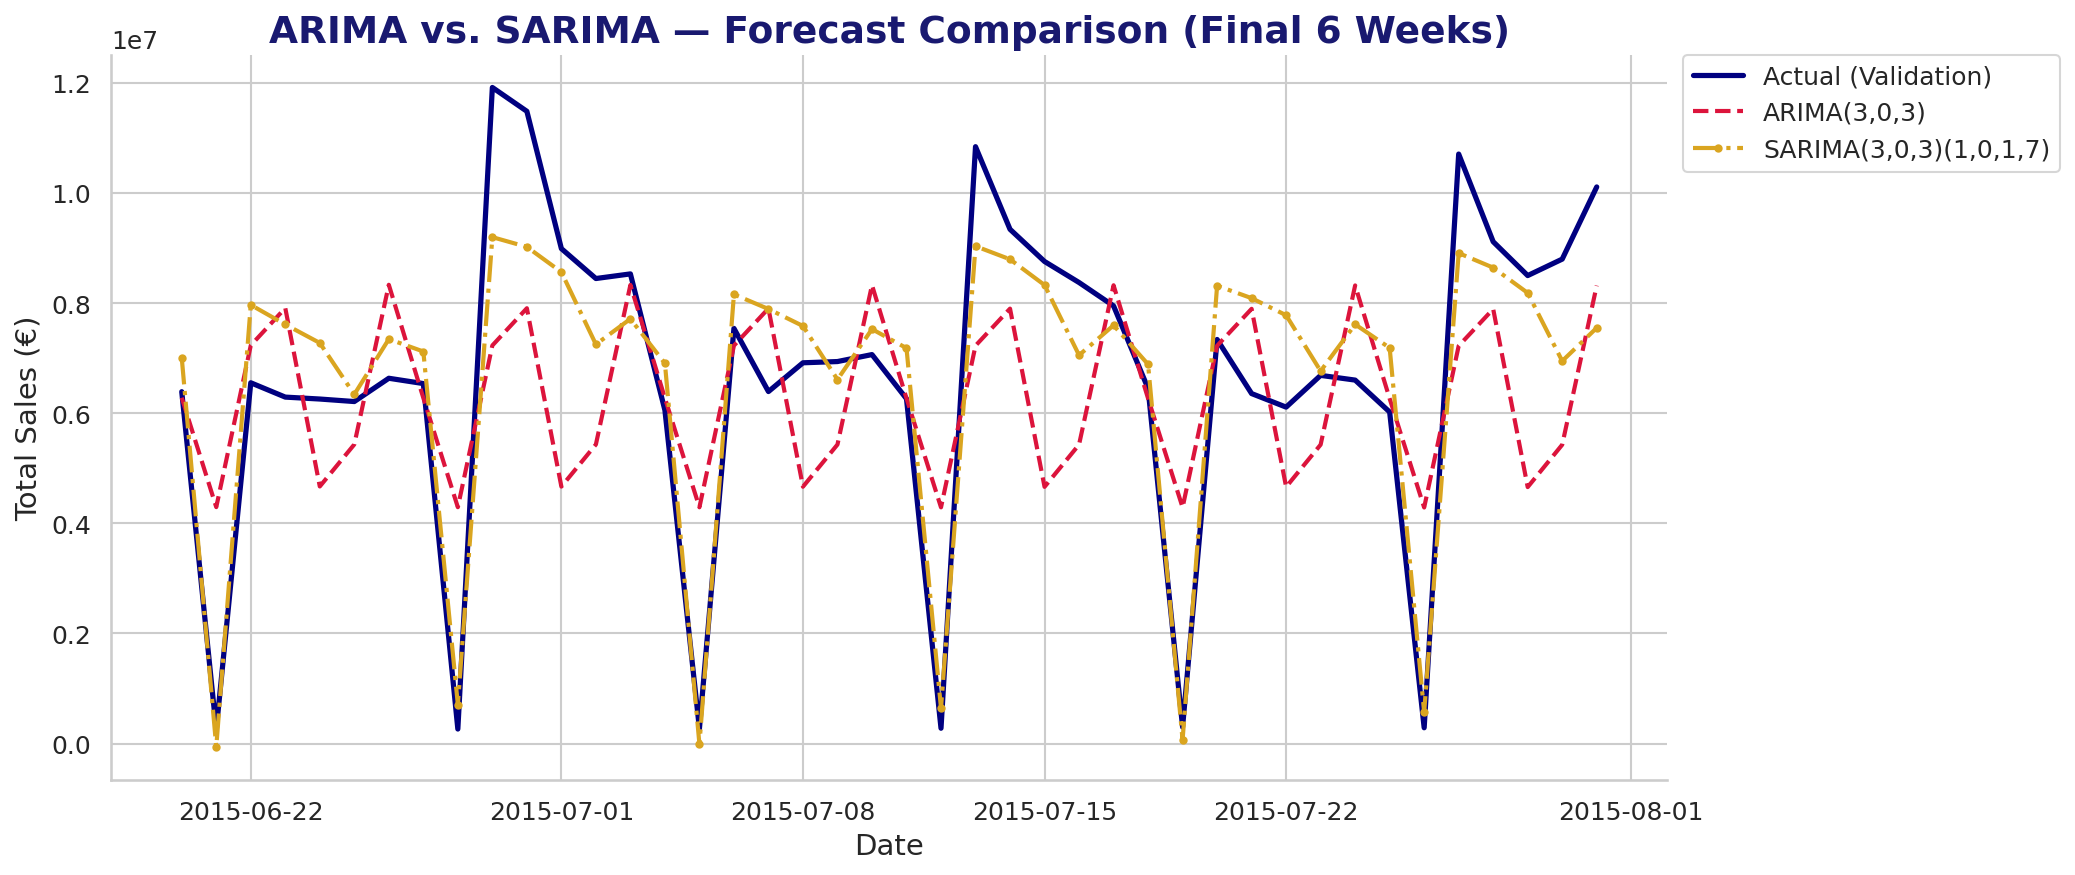

In [19]:
section_header("ARIMA vs. SARIMA Comparison")
subsection_header("Combined Forecast Plot")

plt.figure(figsize=(14, 6))
plt.plot(arima_valid.index, arima_valid.values, color="navy", linewidth=2.5, label="Actual (Validation)")
plt.plot(arima_valid.index, arima_forecast.values, color="crimson", linewidth=2, linestyle="--", label="ARIMA(3,0,3)")
plt.plot(arima_valid.index, sarima_forecast.values, color="goldenrod", linewidth=2, linestyle="-.", marker="o", markersize=3, label="SARIMA(3,0,3)(1,0,1,7)")
plt.title("ARIMA vs. SARIMA — Forecast Comparison (Final 6 Weeks)",fontweight='bold',fontsize=18)
plt.xlabel("Date")
plt.ylabel("Total Sales (€)")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig("Assets/TS_arima_vs_sarima_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
subsection_header("Metrics Comparison")

comparison_df = pd.DataFrame({
    "Model": ["ARIMA(3,0,3)", "SARIMA(3,0,3)(1,0,1,7)"],
    "R²": [f"{arima_r2: .4f}", f"{sarima_r2: .4f}"],
    "MAE": [f"€{arima_mae:,.2f}", f"€{sarima_mae:,.2f}"],
    "RMSE": [f"€{arima_rmse:,.2f}", f"€{sarima_rmse:,.2f}"],
    "RMSPE": [f"{arima_rmspe:.2f}%", f"{sarima_rmspe:.2f}%"]
})
centered_table(comparison_df)

logger.info(f"ARIMA vs SARIMA comparison: ARIMA R2={arima_r2:.4f}/RMSPE={arima_rmspe:.2f}%, "
            f"SARIMA R2={sarima_r2:.4f}/RMSPE={sarima_rmspe:.2f}%.")

Model,R²,MAE,RMSE,RMSPE
"ARIMA(3,0,3)",0.2957,"€2,056,914.87","€2,548,081.01",557.87%
"SARIMA(3,0,3)(1,0,1,7)",0.8558,"€933,252.19","€1,153,044.57",47.90%


2026-09-11 23:26:46 - 04_salesfc_time_series - INFO - ARIMA vs SARIMA comparison: ARIMA R2=0.2957/RMSPE=557.87%, SARIMA R2=0.8558/RMSPE=47.90%.


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — ARIMA vs. SARIMA Comparison:**

- The seasonal component is the entire story here: **R²** improves from **0.2957 to 0.8558**, **RMSPE** drops from **557.87% to 47.90%**, and both **MAE (€2,056,914.87 → €933,252.19)** and **RMSE (€2,548,081.01 → €1,153,044.57)** fall by more than half — using the identical non-seasonal (3,0,3) order in both models, with only the seasonal (1,0,1,7) term added.
- The chart makes the mechanism visible: ARIMA's forecast oscillates on a muted, roughly-weekly rhythm that never actually reaches the real troughs and peaks, while SARIMA's line closely tracks both the Sunday collapses and the weekday recoveries. ARIMA is structurally guessing at the shape of a cycle it has no explicit term for; SARIMA is modeling that cycle directly.
- Both models still noticeably underforecast the largest weekly peaks (visible where the actual line spikes above both dashed forecasts) — plausible evidence of one or more high-volume promotional or holiday-adjacent days inside the validation window that neither model's fixed seasonal pattern fully captures.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 07. Forecast Evaluation: Statistical vs. Deep Learning (Aggregate)

<div style="margin-left: 20px; max-width: 90%">

A fair comparison against ARIMA and SARIMA requires a deep learning model trained under the same constraint they face — the earlier per-store LSTM had access to rich categorical features (StoreType, Promo, Assortment) that ARIMA/SARIMA never see; it isn't a fair benchmark for this notebook's purely univariate task. This section trains a new LSTM directly on the aggregate daily Sales series, architecturally consistent with the earlier LSTM (two layers) but fit strictly on the training portion only, then evaluates all three univariate models — ARIMA, SARIMA, and this new LSTM — on the identical validation window using a single shared metrics function.

</div>

In [21]:
section_header("Forecast Evaluation: Statistical vs. Deep Learning (Aggregate)")
subsection_header("Building the Univariate Aggregate LSTM")

lookback = 14

scaler = MinMaxScaler(feature_range=(-1, 1))
train_scaled = scaler.fit_transform(arima_train.values.reshape(-1, 1))

X_train_seq, y_train_seq = [], []
for i in range(lookback, len(train_scaled)):
    X_train_seq.append(train_scaled[i - lookback:i, 0])
    y_train_seq.append(train_scaled[i, 0])
X_train_seq, y_train_seq = np.array(X_train_seq), np.array(y_train_seq)
X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], X_train_seq.shape[1], 1))

try:
    agg_lstm = load_latest_model_artifact(
        "final_aggregate_lstm_*.keras",
        loader=keras.models.load_model,
        drive_dir=DRIVE_ASSETS_DIR if DRIVE_MOUNTED else None,
        github_api_dir=GITHUB_CONTENTS_URL,
        logger=logger
    )
    history = None
    info_box("Existing aggregate LSTM found — loaded directly, training skipped.")
    logger.info("Aggregate LSTM loaded from existing artifact, training skipped.")
except FileNotFoundError:
    agg_lstm = Sequential([
        Input(shape=(lookback, 1)),
        LSTM(64, activation="tanh", return_sequences=True),
        LSTM(32, activation="tanh"),
        Dense(1)
    ])
    agg_lstm.compile(optimizer="adam", loss="mse")
    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    info_box("No existing artifact found — training univariate aggregate LSTM for a fair comparison against ARIMA and SARIMA...")
    history = agg_lstm.fit(
        X_train_seq, y_train_seq,
        validation_split=0.1,
        epochs=100, batch_size=32,
        callbacks=[early_stop], verbose=0
    )
    success_box(f"Aggregate LSTM trained ({len(history.history['loss'])} epochs, early-stopped).")
    logger.info(f"Aggregate LSTM trained for {len(history.history['loss'])} epochs (early-stopped).")

inputs = pd.concat([arima_train[-lookback:], arima_valid]).values.reshape(-1, 1)
inputs_scaled = scaler.transform(inputs)

X_test_seq = []
for i in range(lookback, len(inputs_scaled)):
    X_test_seq.append(inputs_scaled[i - lookback:i, 0])
X_test_seq = np.array(X_test_seq).reshape((-1, lookback, 1))

lstm_scaled_pred = agg_lstm.predict(X_test_seq, verbose=0)
lstm_forecast = scaler.inverse_transform(lstm_scaled_pred).flatten()

info_box("Validation forecasts generated.")
logger.info("Aggregate LSTM validation predictions generated.")

2026-09-11 23:26:46 - 04_salesfc_time_series - INFO - Loaded latest local model artifact: Assets/final_aggregate_lstm_11-09-2026-08-58-56.keras


2026-09-11 23:26:46 - 04_salesfc_time_series - INFO - Aggregate LSTM loaded from existing artifact, training skipped.


2026-09-11 23:26:48 - 04_salesfc_time_series - INFO - Aggregate LSTM validation predictions generated.


In [22]:
subsection_header("Saving the Aggregate LSTM")

if history is not None:
    agg_lstm_timestamp = datetime.now().strftime("%d-%m-%Y-%H-%M-%S")
    agg_lstm_filename = f"final_aggregate_lstm_{agg_lstm_timestamp}.keras"
    agg_lstm_path = f"Assets/{agg_lstm_filename}"
    agg_lstm.save(agg_lstm_path)
    if DRIVE_MOUNTED:
        agg_lstm.save(f"{DRIVE_ASSETS_DIR}/{agg_lstm_filename}")
        success_box(f"Aggregate LSTM saved locally to <b>{agg_lstm_path}</b> and mirrored to Drive.")
    else:
        success_box(f"Aggregate LSTM saved locally to <b>{agg_lstm_path}</b>. Drive not mounted — no mirror made.")
    logger.info(f"Aggregate LSTM serialized to {agg_lstm_path}.")
else:
    info_box("Loaded from an existing artifact — no new save needed.")
    logger.info("Skipped saving — using existing aggregate LSTM artifact.")

2026-09-11 23:26:48 - 04_salesfc_time_series - INFO - Skipped saving — using existing aggregate LSTM artifact.


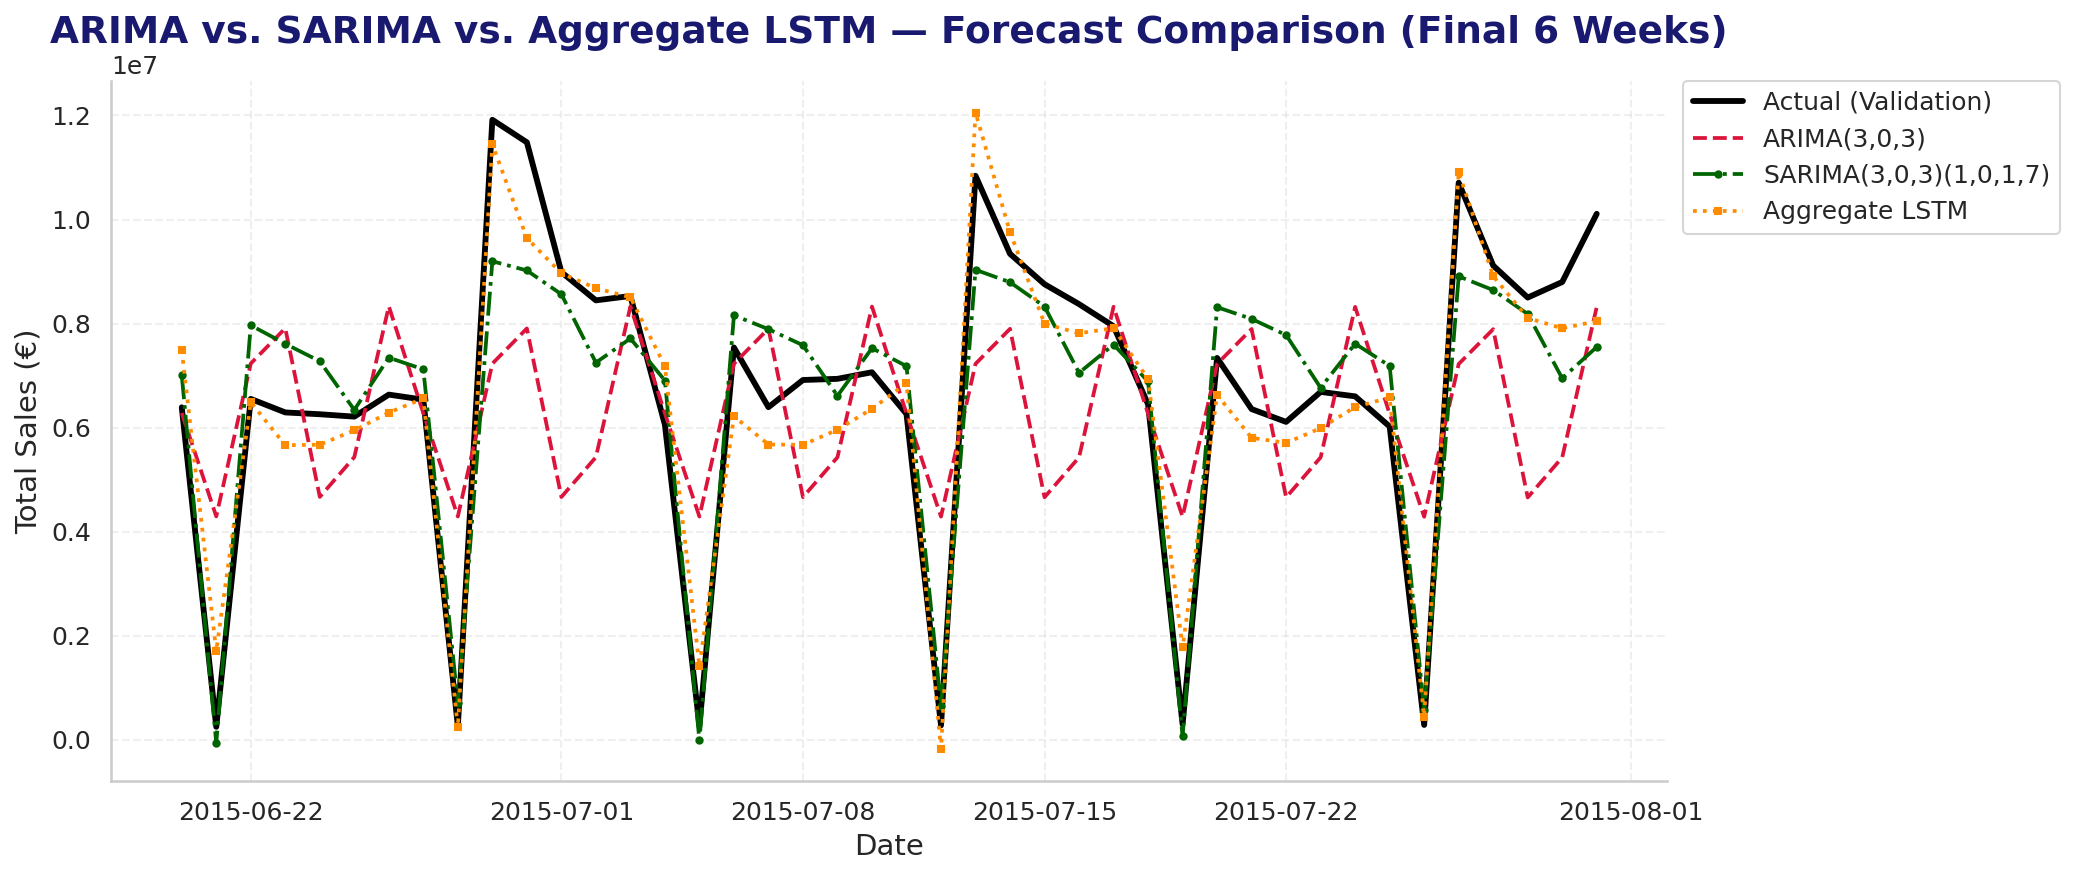

2026-09-11 23:26:49 - 04_salesfc_time_series - INFO - Forecast comparison plot generated.


In [23]:

subsection_header("Forecast Comparison — ARIMA vs. SARIMA vs. Aggregate LSTM")

plt.figure(figsize=(14, 6))
plt.plot(arima_valid.index, arima_valid.values, color="black", linewidth=2.8, label="Actual (Validation)")
plt.plot(arima_valid.index, arima_forecast.values, color="crimson", linewidth=1.8, linestyle="--", label="ARIMA(3,0,3)")
plt.plot(arima_valid.index, sarima_forecast.values, color="darkgreen", linewidth=1.8, linestyle="-.", marker="o", markersize=3, label="SARIMA(3,0,3)(1,0,1,7)")
plt.plot(arima_valid.index, lstm_forecast, color="darkorange", linewidth=1.8, linestyle=":", marker="s", markersize=3, label="Aggregate LSTM")
plt.title("ARIMA vs. SARIMA vs. Aggregate LSTM — Forecast Comparison (Final 6 Weeks)",fontweight='bold',fontsize=18)
plt.xlabel("Date")
plt.ylabel("Total Sales (€)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig("Assets/TS_forecast_evaluation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
logger.info("Forecast comparison plot generated.")

In [24]:
subsection_header("Comprehensive Forecast Evaluation (Metrics)")

def eval_metrics(actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)
    mask = actual != 0
    rmspe = np.sqrt(np.mean(np.square((actual[mask] - pred[mask]) / actual[mask]))) * 100
    return r2, mae, rmse, rmspe

eval_arima_r2, eval_arima_mae, eval_arima_rmse, eval_arima_rmspe = eval_metrics(arima_valid.values, arima_forecast.values)
eval_sarima_r2, eval_sarima_mae, eval_sarima_rmse, eval_sarima_rmspe = eval_metrics(arima_valid.values, sarima_forecast.values)
eval_lstm_r2, eval_lstm_mae, eval_lstm_rmse, eval_lstm_rmspe = eval_metrics(arima_valid.values, lstm_forecast)

forecast_eval_df = pd.DataFrame({
    "Model": ["ARIMA(3,0,3)", "SARIMA(3,0,3)(1,0,1,7)", "Aggregate LSTM (14-Day Window)"],
    "R²": [f"{eval_arima_r2:.4f}", f"{eval_sarima_r2:.4f}", f"{eval_lstm_r2:.4f}"],
    "MAE": [f"€{eval_arima_mae:,.2f}", f"€{eval_sarima_mae:,.2f}", f"€{eval_lstm_mae:,.2f}"],
    "RMSE": [f"€{eval_arima_rmse:,.2f}", f"€{eval_sarima_rmse:,.2f}", f"€{eval_lstm_rmse:,.2f}"],
    "RMSPE": [f"{eval_arima_rmspe:.2f}%", f"{eval_sarima_rmspe:.2f}%", f"{eval_lstm_rmspe:.2f}%"]
})
centered_table(forecast_eval_df)

logger.info(f"Forecast evaluation complete. ARIMA R2={eval_arima_r2:.4f}/RMSPE={eval_arima_rmspe:.2f}%, "
            f"SARIMA R2={eval_sarima_r2:.4f}/RMSPE={eval_sarima_rmspe:.2f}%, "
            f"Aggregate LSTM R2={eval_lstm_r2:.4f}/RMSPE={eval_lstm_rmspe:.2f}%.")

Model,R²,MAE,RMSE,RMSPE
"ARIMA(3,0,3)",0.2957,"€2,056,914.87","€2,548,081.01",557.87%
"SARIMA(3,0,3)(1,0,1,7)",0.8558,"€933,252.19","€1,153,044.57",47.90%
Aggregate LSTM (14-Day Window),0.9266,"€651,332.88","€822,374.17",137.76%


2026-09-11 23:26:49 - 04_salesfc_time_series - INFO - Forecast evaluation complete. ARIMA R2=0.2957/RMSPE=557.87%, SARIMA R2=0.8558/RMSPE=47.90%, Aggregate LSTM R2=0.9266/RMSPE=137.76%.


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Forecast Evaluation: Statistical vs. Deep Learning (Aggregate):**

- The aggregate LSTM posts the strongest R² (0.9266) and lowest MAE (€651,332.88) of the three models — ahead of SARIMA's R² of 0.8558 and MAE of €933,252.19 — yet its RMSPE (137.76%) is still notably worse than SARIMA's (47.90%). This isn't a contradiction: R² and MAE reward overall fit and average absolute accuracy, where the LSTM excels, while RMSPE specifically penalizes percentage error, which balloons on the near-zero Sunday troughs visible in the chart — a modest absolute miss becomes an enormous percentage miss when the true value is close to zero. SARIMA's explicit seasonal term tracks those specific troughs more precisely, which is exactly what RMSPE rewards.
- This is a genuinely useful finding on its own: which model "wins" depends on which metric matters for the business question — overall fit and typical error (LSTM), or being specifically accurate on the extreme low-sales days (SARIMA).
- Both SARIMA and the aggregate LSTM comfortably beat ARIMA on every metric, confirming that accounting for the weekly seasonal pattern — whether through explicit seasonal terms or a model with enough capacity to learn the pattern implicitly — is what drives performance here.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 08. Model Serialization

<div style="margin-left: 20px; max-width: 90%">

The aggregate LSTM already has its own save/load cycle built into the forecast evaluation step. This section handles the two models that don't — the fitted ARIMA and SARIMA objects — following the same timestamped, Local-plus-Drive-mirror pattern used for every other serialized artifact in this project.

</div>

In [25]:
section_header("Model Serialization")
subsection_header("Saving ARIMA and SARIMA")

ts_timestamp = datetime.now().strftime("%d-%m-%Y-%H-%M-%S")

arima_filename = f"final_arima_model_{ts_timestamp}.pkl"
arima_path = f"Assets/{arima_filename}"
joblib.dump(arima_fitted, arima_path)

sarima_filename = f"final_sarima_model_{ts_timestamp}.pkl"
sarima_path = f"Assets/{sarima_filename}"
joblib.dump(sarima_fitted, sarima_path)

if DRIVE_MOUNTED:
    joblib.dump(arima_fitted, f"{DRIVE_ASSETS_DIR}/{arima_filename}")
    joblib.dump(sarima_fitted, f"{DRIVE_ASSETS_DIR}/{sarima_filename}")
    success_box(f"ARIMA saved to <b>{arima_path}</b> and mirrored to Drive.<br>"
                f"SARIMA saved to <b>{sarima_path}</b> and mirrored to Drive.")
else:
    success_box(f"ARIMA saved to <b>{arima_path}</b>. SARIMA saved to <b>{sarima_path}</b>. Drive not mounted — no mirror made.")

logger.info(f"ARIMA serialized to {arima_path}. SARIMA serialized to {sarima_path}.")

2026-09-11 23:26:49 - 04_salesfc_time_series - INFO - ARIMA serialized to Assets/final_arima_model_11-09-2026-23-26-49.pkl. SARIMA serialized to Assets/final_sarima_model_11-09-2026-23-26-49.pkl.


## 09. Final Model Comparison

<div style="margin-left: 20px; max-width: 90%">

This section places every model built across the project side by side — the Random Forest and LSTM/GRU from earlier notebooks (per-store, multivariate) alongside this notebook's ARIMA, SARIMA, and aggregate LSTM (network-wide, univariate) — and draws a single conclusion about which approach performed best, and under what conditions.

</div>

In [26]:
section_header("Final Model Comparison")
subsection_header("All Models — Side by Side")

final_comparison_df = pd.DataFrame({
    "Model": [
        "Tuned Random Forest (per-store)",
        "LSTM 2-Layer (per-store)",
        "ARIMA(3,0,3) (aggregate)",
        "SARIMA(3,0,3)(1,0,1,7) (aggregate)",
        "Aggregate LSTM (aggregate)"
    ],
    "Target": ["Per-store", "Per-store","Network-wide aggregate", "Network-wide aggregate", "Network-wide aggregate"],
    "R²": ["0.9621", "0.8361", f"{eval_arima_r2:.4f}", f"{eval_sarima_r2:.4f}", f"{eval_lstm_r2:.4f}"],
    "RMSPE": ["8.05%", "19.45%", f"{eval_arima_rmspe:.2f}%", f"{eval_sarima_rmspe:.2f}%", f"{eval_lstm_rmspe:.2f}%"]
})
centered_table(final_comparison_df)
logger.info("Final cross-notebook model comparison table rendered.")


Model,Target,R²,RMSPE
Tuned Random Forest (per-store),Per-store,0.9621,8.05%
LSTM 2-Layer (per-store),Per-store,0.8361,19.45%
"ARIMA(3,0,3) (aggregate)",Network-wide aggregate,0.2957,557.87%
"SARIMA(3,0,3)(1,0,1,7) (aggregate)",Network-wide aggregate,0.8558,47.90%
Aggregate LSTM (aggregate),Network-wide aggregate,0.9266,137.76%


2026-09-11 23:26:49 - 04_salesfc_time_series - INFO - Final cross-notebook model comparison table rendered.


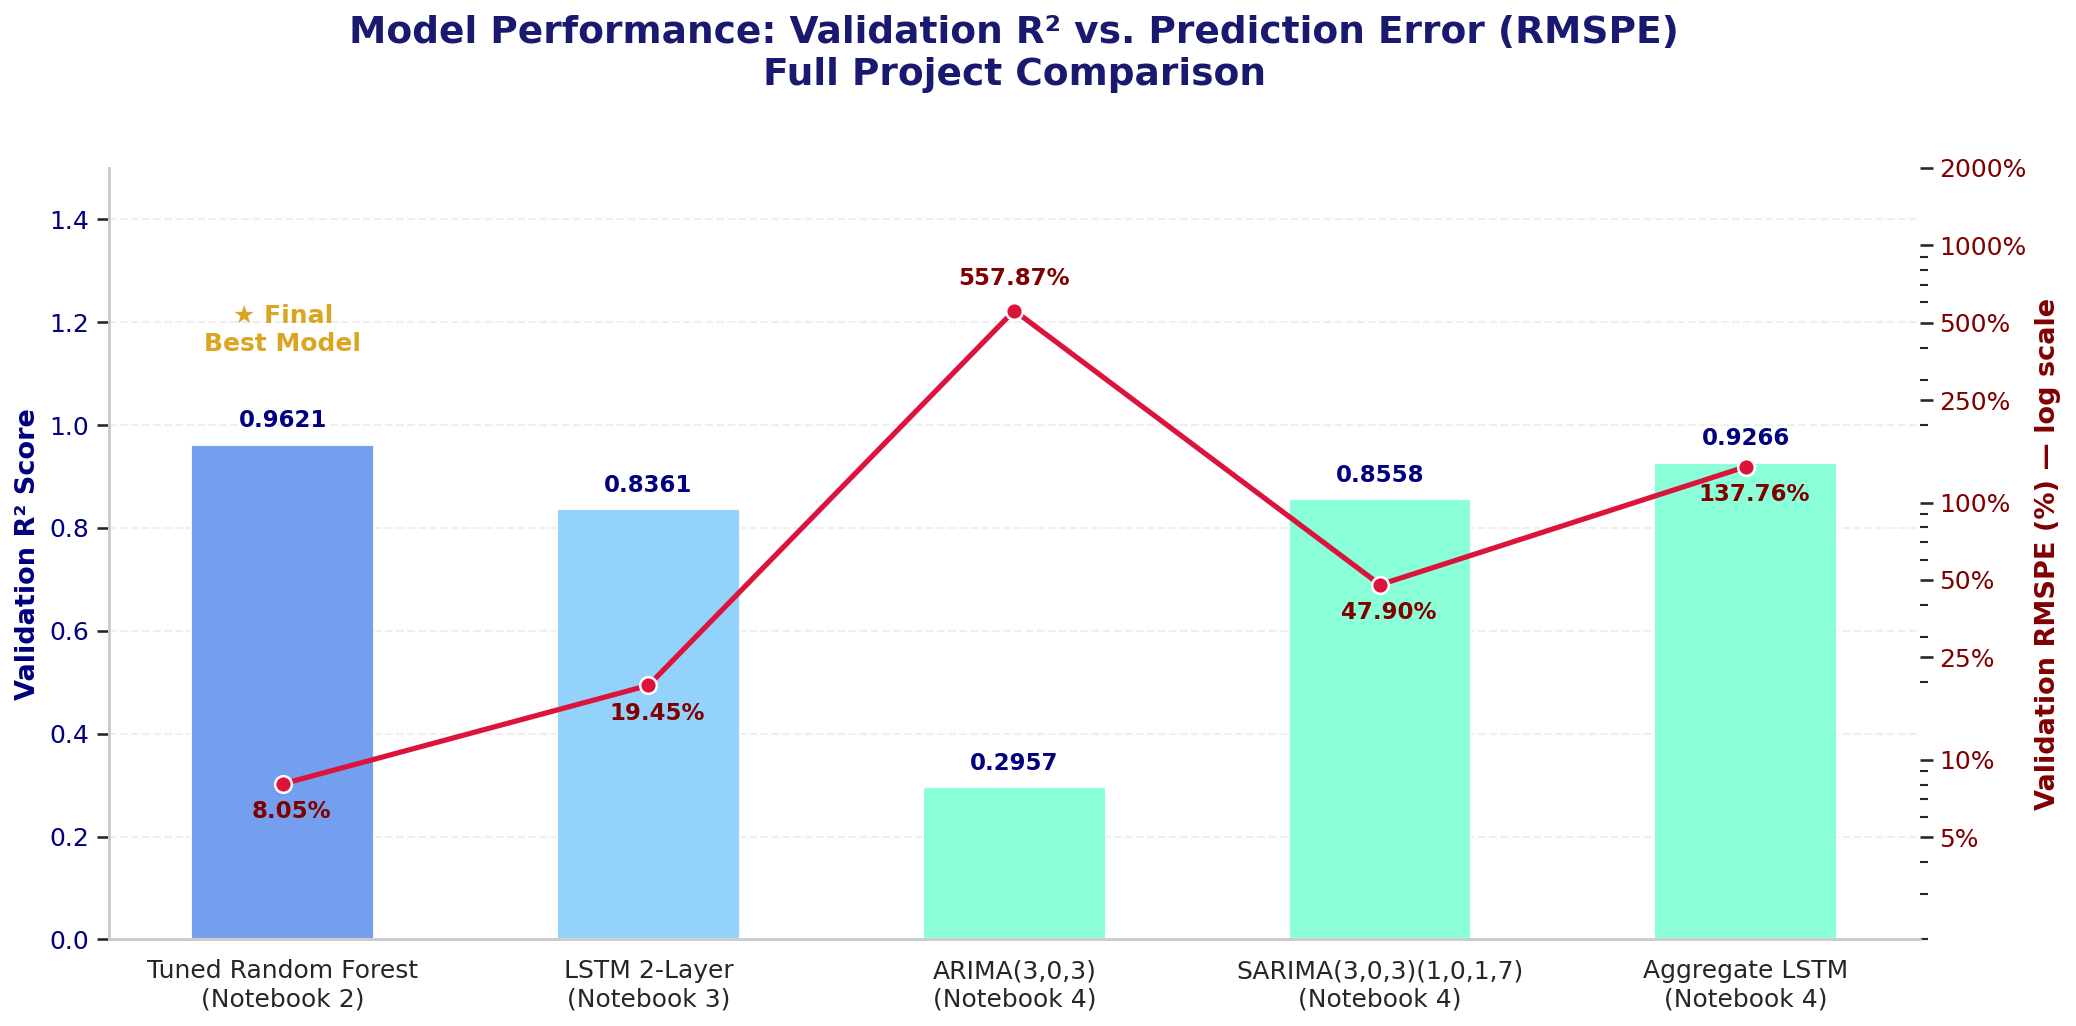

2026-09-12 00:41:05 - 04_salesfc_time_series - INFO - Final all-model R2 vs RMSPE dual-axis comparison chart rendered.


In [50]:
subsection_header("Visual Comparison — R² vs. RMSPE Across All Models")

models = [
    "Tuned Random Forest\n(Notebook 2)", "LSTM 2-Layer\n(Notebook 3)",
    "ARIMA(3,0,3)\n(Notebook 4)", "SARIMA(3,0,3)(1,0,1,7)\n(Notebook 4)", "Aggregate LSTM\n(Notebook 4)"
]
r2_scores = [0.9621, 0.8361, eval_arima_r2, eval_sarima_r2, eval_lstm_r2]
rmspe_scores = [8.05, 19.45, eval_arima_rmspe, eval_sarima_rmspe, eval_lstm_rmspe]

fig, ax1 = plt.subplots(figsize=(14, 7))

bar_colors = ["cornflowerblue", "lightskyblue", "aquamarine", "aquamarine", "aquamarine"]
bars = ax1.bar(models, r2_scores, color=bar_colors, width=0.5, alpha=0.9)
ax1.set_ylabel("Validation R² Score", fontweight="bold", fontsize=13, color="navy")
ax1.set_ylim(0, 1.5)
ax1.tick_params(axis="y", labelcolor="navy")
ax1.grid(True, axis='y', linestyle="--", alpha=0.3)
ax1.grid(False, axis='x')
for bar, r2 in zip(bars, r2_scores):
    ax1.annotate(f"{r2:.4f}", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 xytext=(0, 6), textcoords="offset points", ha="center", va="bottom",
                 fontweight="bold", fontsize=11, color="navy")

best_idx = int(np.argmin(rmspe_scores))
ax1.annotate("★ Final\nBest Model", xy=(best_idx, r2_scores[best_idx]),
             xytext=(0, 45), textcoords="offset points", ha="center",
             fontweight="bold", fontsize=12, color="goldenrod")

ax2 = ax1.twinx()
ax2.plot(models, rmspe_scores, color="crimson", marker="o", markersize=8, linewidth=2.5, markeredgecolor="white", markeredgewidth=1.2)
ax2.set_ylabel("Validation RMSPE (%) — log scale", fontweight="bold", fontsize=13, color="maroon")
ax2.set_yscale("log")
ax2.set_ylim(2, 2000)
ax2.set_yticks([5, 10, 25, 50, 100, 250, 500, 1000, 2000])
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y)}%"))
ax2.tick_params(axis="y", labelcolor="maroon")
ax2.grid(False)

for i, txt in enumerate(rmspe_scores):
    offset = (0, 10) if txt > 200 else (4, -19)
    ax2.annotate(f"{txt:.2f}%", xy=(i, txt), xytext=offset, textcoords="offset points",
                 ha="center", va="bottom", fontweight="bold", fontsize=11, color="maroon")

ax1.set_title("Model Performance: Validation R² vs. Prediction Error (RMSPE)\nFull Project Comparison",
              fontweight="bold", fontsize=18, pad=40)
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Assets/TS_final_all_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

logger.info("Final all-model R2 vs RMSPE dual-axis comparison chart rendered.")

In [28]:
subsection_header("Final Verdict")

verdict_html = f"""
<div style="background:#F1F3F6;border-left:6px solid #1F77B4;padding:16px;border-radius:6px;margin:15px 0;line-height:1.6;">
    <div style="color:#1F77B4;font-size:18px;font-weight:bold;margin-bottom:8px;">🏆 Final Verdict: Machine Learning Wins</div>
    <div style="color:black;">
        Across every approach tried in this project — tree-based, per-store deep learning, classical statistical, and univariate deep learning — the <b>Tuned Random Forest</b> remains the strongest model, capturing <b>{r2_scores[0]*100:.2f}%</b> of the variance with a <b>{rmspe_scores[0]:.2f}%</b> RMSPE.<br><br>
        <b>Why did this hold up even against a dedicated time-series notebook?</b> Retail sales are driven by discrete, high-signal categorical features — Store identity, Promo, StoreType, CompetitionDistance — which tree-based models split on natively and effectively. ARIMA, SARIMA, and the aggregate LSTM were all restricted to a single univariate series by design, and no amount of seasonal modeling or sequence learning fully closed that feature-access gap.
    </div>
</div>
"""
display(HTML(verdict_html))
logger.info(f"Final Verdict rendered. Tuned RF (RMSPE {rmspe_scores[0]}%) remains the overall project winner.")

2026-09-11 23:26:51 - 04_salesfc_time_series - INFO - Final Verdict rendered. Tuned RF (RMSPE 8.05%) remains the overall project winner.


## 10. Final Summary

<div style="margin-left: 20px; max-width: 90%">

This notebook applied classical time series and univariate deep learning approaches to Rossmann sales forecasting, as a direct comparison point to the per-store models built in earlier notebooks. Key milestones:

*   **Time Series Preparation:** The aggregate daily sales series was confirmed stationary (ADF p = 0.000064) with no differencing required. ACF/PACF analysis revealed strong weekly-cycle-driven autocorrelation clustered around multiples of 7, directly informing the seasonal period used throughout this notebook.
*   **ARIMA vs. SARIMA:** Plain ARIMA(3,0,3) converged cleanly but performed poorly (RMSPE 557.87%) — structurally unable to represent the weekly cycle. Adding a seasonal term (SARIMA(3,0,3)(1,0,1,7)) improved RMSPE more than tenfold, to 47.90%, directly validating the seasonal hypothesis from the diagnostics stage.
*   **Aggregate LSTM:** A univariate LSTM, trained strictly on the training portion to avoid leakage, achieved the best R² (0.9266) and lowest MAE (€651,332.88) of the three aggregate-series models — but a weaker RMSPE (137.76%) than SARIMA, illustrating that different metrics can favor different models depending on what they penalize.
*   **Full Project Comparison:** Every aggregate-series model — classical or deep learning — trailed the Tuned Random Forest (RMSPE 8.05%) by a wide margin, reinforcing that richer per-store input features mattered more than model sophistication across this entire project.
*   **Reproducibility Note:** Both ARIMA's maximum-likelihood optimization and LSTM training showed run-to-run numerical variability on identical data/code — a documented characteristic of these optimization methods, not a pipeline defect. Reported figures reflect the final, artifact-locked run.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

In [29]:
display(HTML(f"""
<div style="text-align:center;">
    <h3 style="color:#2E8B57;">✅ Checkpoint: End of Notebook 4</h3>
    <p style="font-style:italic;">
        Time series modeling complete — ARIMA, SARIMA, and the aggregate LSTM are all fit, evaluated,
        and serialized. Combined with the Tuned Random Forest and per-store LSTM/GRU from earlier
        notebooks, every model this project set out to build now has a final, validated result.
        Next: the Streamlit dashboard, built in VS Code.
    </p>
    <hr style="width:45%;margin:auto;">
</div>
"""))